In [1]:
import pandas as pd
import seaborn as sns
import os 
import matplotlib.pyplot as plt

os.chdir('/Users/felixdiederichs/PycharmProjects/Data_Analysis/.venv/Analyse/Obesity')

In [2]:
data = pd.read_csv('/Users/felixdiederichs/PycharmProjects/Data_Analysis/.venv/Analyse/Obesity/obesity_resemblance.csv')
data

,Model,Epochs,Lambda,Proportion positive numerical tests,Proportion positive categorical tests,Proportion distances below threshold,Proportion positive numerical correlations,Proportion positive categorical correlations,Average DLA,Proportion positive numerical tests 2,...,Proportion positive numerical tests 3,Proportion positive categorical tests 3,Proportion distances below threshold 3,Proportion positive numerical correlations 3,Proportion positive categorical correlations 3,Average DLA 3,URA Score,MRA Score,DLA Score,Overall Score
0,tabfairgan,50,0.2,0.308333,0.033333,0.845833,0.626,0.543,0.793393,Good,...,2,2,3,3,2,2,2.31,2.5,2,2.324
1,tabfairgan,50,0.4,0.275000,0.033333,0.858333,0.602,0.489,0.793218,Good,...,2,2,3,3,2,2,2.31,2.5,2,2.324
2,tabfairgan,50,0.6,0.250000,0.077778,0.841667,0.597,0.474,0.793478,Good,...,2,2,3,2,2,2,2.31,2.0,2,2.124
3,tabfairgan,50,0.8,0.304167,0.111111,0.850000,0.610,0.586,0.785270,Good,...,2,2,3,3,2,2,2.31,2.5,2,2.324
4,tabfairgan,50,1.0,0.262500,0.022222,0.841667,0.583,0.566,0.796911,Good,...,2,2,3,2,2,2,2.31,2.0,2,2.124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,ctgan,100,NaN,0.241667,0.011111,0.887500,0.608,0.493,0.812313,Good,...,2,2,3,3,2,1,2.31,2.5,1,2.124
158,ctgan,150,NaN,0.220833,0.011111,0.883333,0.621,0.516,0.807785,Good,...,2,2,3,3,2,1,2.31,2.5,1,2.124
159,ctgan,200,NaN,0.220833,0.033333,0.870833,0.618,0.561,0.806137,Good,...,2,2,3,3,2,1,2.31,2.5,1,2.124
160,ctgan,250,NaN,0.183333,0.044444,0.875000,0.662,0.514,0.805369,Good,...,2,2,3,3,2,1,2.31,2.5,1,2.124


# Resemblance Analysis

#### Overall Resemblance Score

<Axes: xlabel='Model', ylabel='Overall Score'>

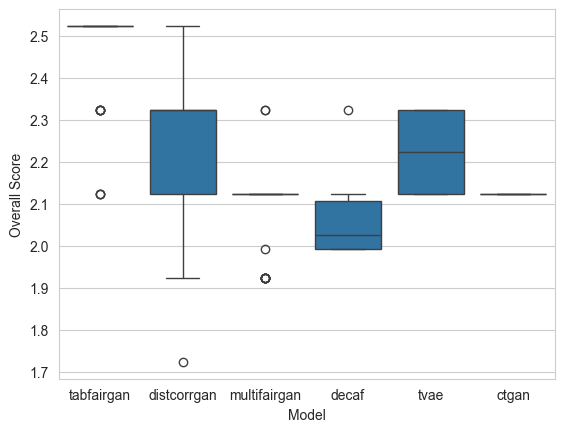

In [3]:
sns.boxplot(x='Model', y='Overall Score', data=data)

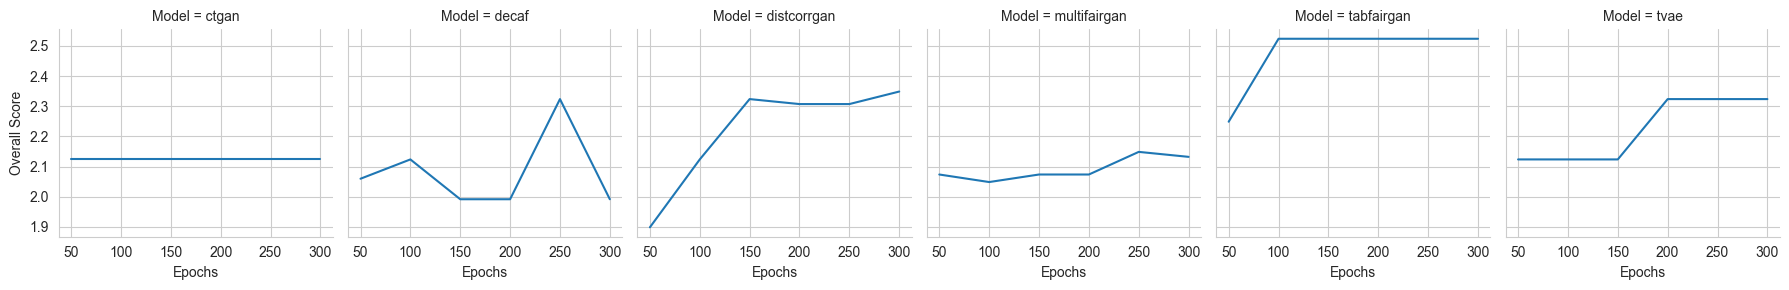

In [19]:
group_overall_score = data.groupby(['Model', 'Epochs'])['Overall Score'].mean().reset_index()

fg = sns.FacetGrid(data=group_overall_score, col='Model')
fg.map(sns.lineplot, 'Epochs', 'Overall Score')

## Univariate Resemblance Analysis

#### Overall URA Score

<Axes: xlabel='Model', ylabel='URA Score'>

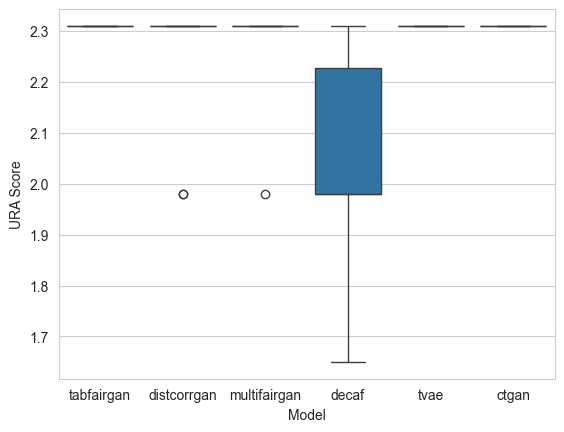

In [4]:
sns.boxplot(x='Model', y='URA Score', data=data)

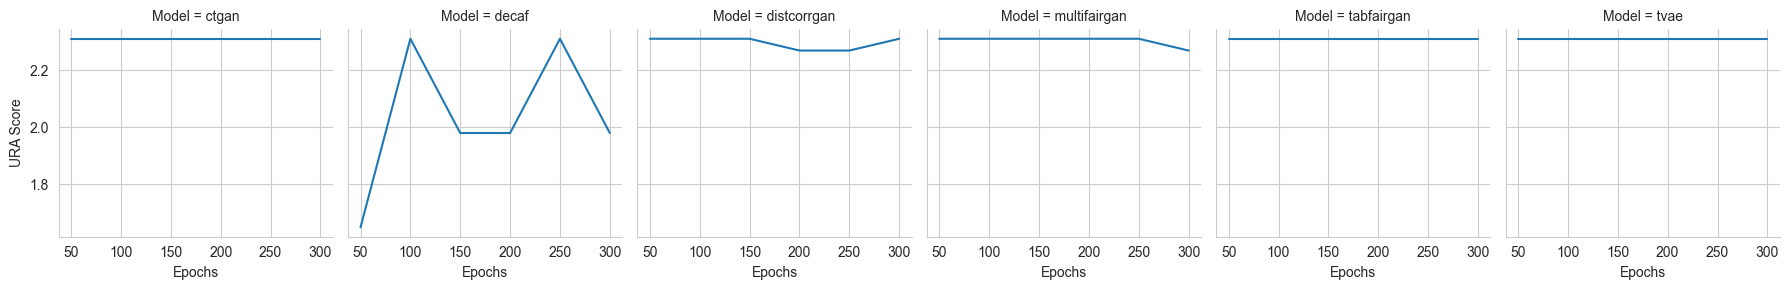

In [5]:
grouped_ura = data.groupby(['Model', 'Epochs'])['URA Score'].mean()
grouped_ura = grouped_ura.reset_index()
pivot_table_ura = grouped_ura.pivot(index='Epochs', columns='Model', values='URA Score')
pivot_table_ura = pivot_table_ura.reset_index()
pivot_table_ura = pivot_table_ura.melt(id_vars='Epochs', var_name='Model', value_name='URA Score')

fg = sns.FacetGrid(data=pivot_table_ura, col='Model')
fg.map(sns.lineplot, 'Epochs', 'URA Score', data=pivot_table_ura)

#### Statistical tests

<Axes: xlabel='Model', ylabel='Proportion positive categorical tests'>

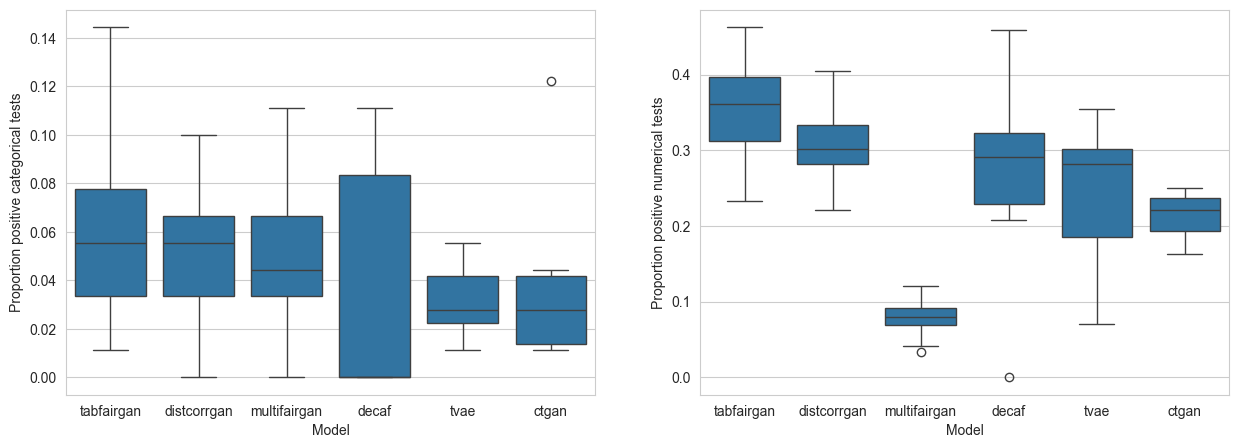

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='Model', y='Proportion positive numerical tests', data=data, ax = axes[1])
sns.boxplot(x='Model', y='Proportion positive categorical tests', data=data, ax = axes[0])

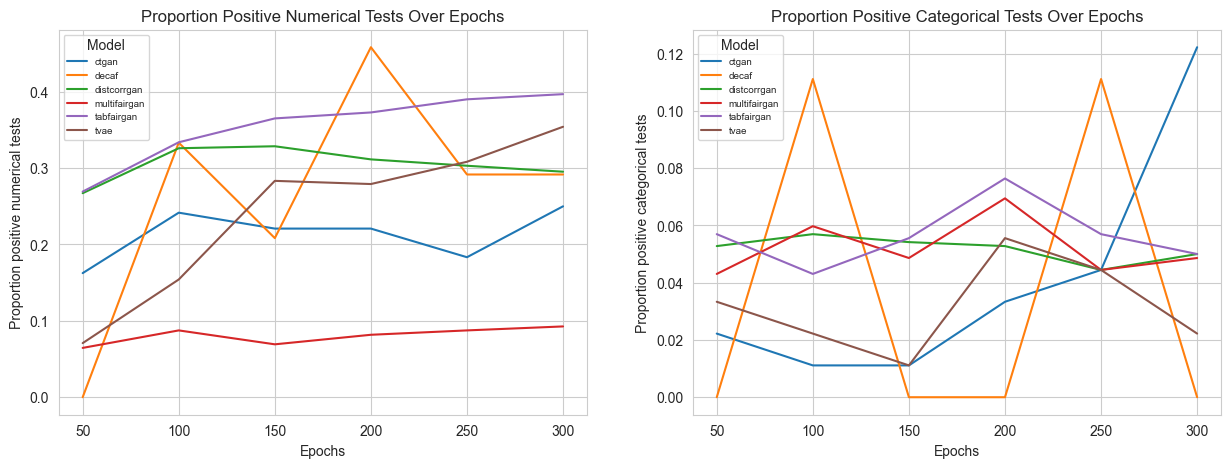

In [17]:
grouped_numerical_tests = data.groupby(['Model', 'Epochs'])['Proportion positive numerical tests'].mean()
grouped_numerical_tests = grouped_numerical_tests.reset_index()
pivot_table_numerical_tests = grouped_numerical_tests.pivot(index='Epochs', columns='Model', values='Proportion positive numerical tests')
pivot_table_numerical_tests = pivot_table_numerical_tests.reset_index()
pivot_table_numerical_tests = pivot_table_numerical_tests.melt(id_vars='Epochs', var_name='Model', value_name='Proportion positive numerical tests')

grouped_categorical_tests = data.groupby(['Model', 'Epochs'])['Proportion positive categorical tests'].mean()
grouped_categorical_tests = grouped_categorical_tests.reset_index()
pivot_table_categorical_tests = grouped_categorical_tests.pivot(index='Epochs', columns='Model', values='Proportion positive categorical tests')
pivot_table_categorical_tests = pivot_table_categorical_tests.reset_index()
pivot_table_categorical_tests = pivot_table_categorical_tests.melt(id_vars='Epochs', var_name='Model', value_name='Proportion positive categorical tests')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot on the first axes
sns.lineplot(x='Epochs', y='Proportion positive numerical tests', hue='Model', data=pivot_table_numerical_tests, ax=axes[0])
axes[0].set_title('Proportion Positive Numerical Tests Over Epochs')
sns.move_legend(axes[0], 'upper left', fontsize=7)

# Clear the second axes before plotting 
axes[1].cla()  # Clear the axes

# Plot on the (now cleared) second axes
sns.lineplot(x='Epochs', y='Proportion positive categorical tests', hue='Model', data=pivot_table_categorical_tests, ax=axes[1])
axes[1].set_title('Proportion Positive Categorical Tests Over Epochs')
sns.move_legend(axes[1], 'upper left', fontsize=7)

#### Distances 

<Axes: xlabel='Model', ylabel='Proportion distances below threshold'>

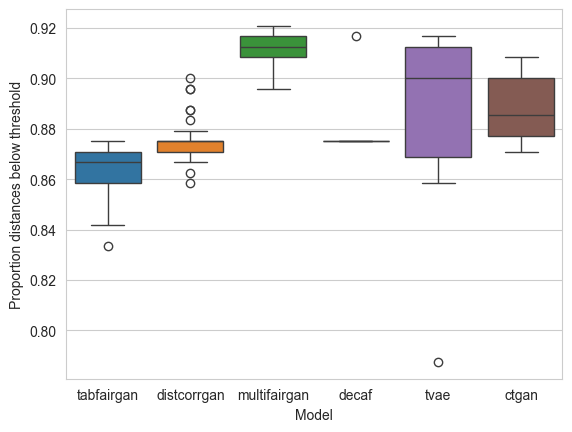

In [8]:
sns.boxplot(x='Model', y='Proportion distances below threshold', hue='Model', data=data)

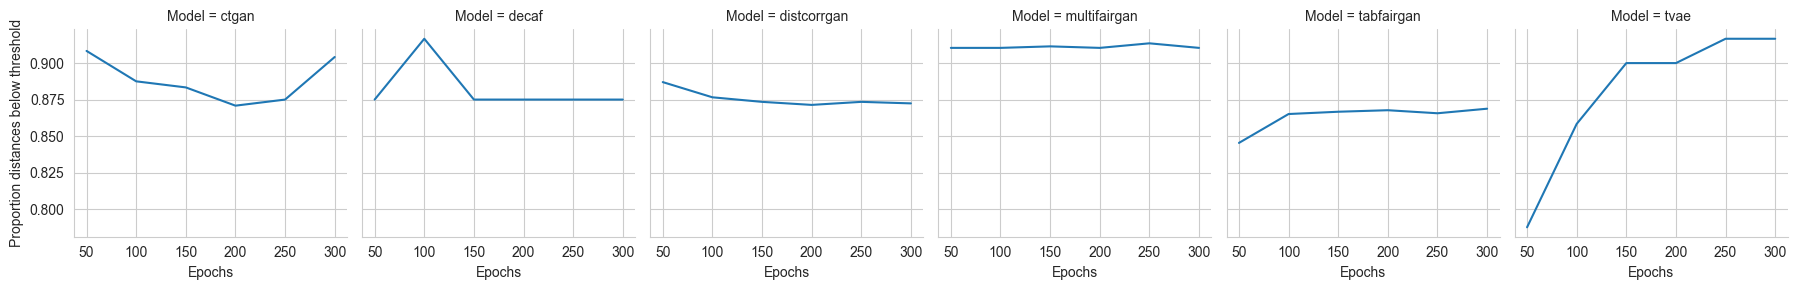

In [9]:
group_distances = data.groupby(['Model', 'Epochs'])['Proportion distances below threshold'].mean().reset_index()

fg = sns.FacetGrid(data=group_distances, col='Model')
fg.map(sns.lineplot, 'Epochs', 'Proportion distances below threshold')

## Multivariate Resemblance Analysis

#### Overall MRA Score

<Axes: xlabel='Model', ylabel='MRA Score'>

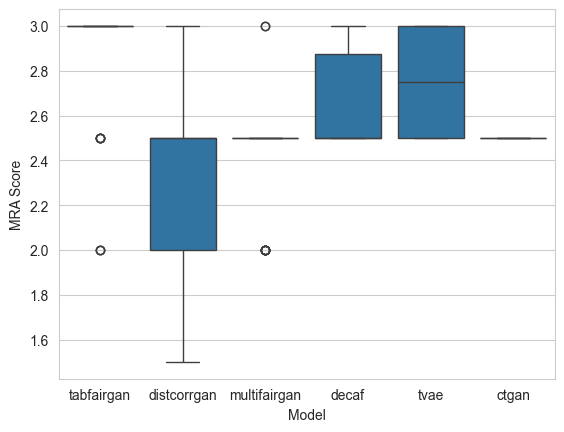

In [21]:
sns.boxplot(x='Model', y='MRA Score', data=data)

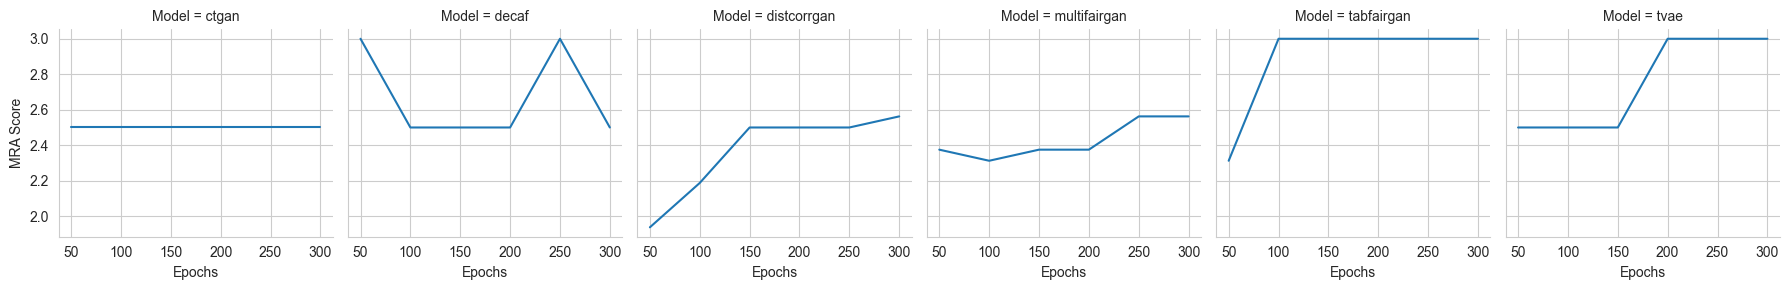

In [24]:
group_mra = data.groupby(['Model', 'Epochs'])['MRA Score'].mean().reset_index()

fg = sns.FacetGrid(data=group_mra, col='Model')
fg.map(sns.lineplot, 'Epochs', 'MRA Score', data=group_mra)

#### Correlations

<Axes: xlabel='Model', ylabel='Proportion positive numerical correlations'>

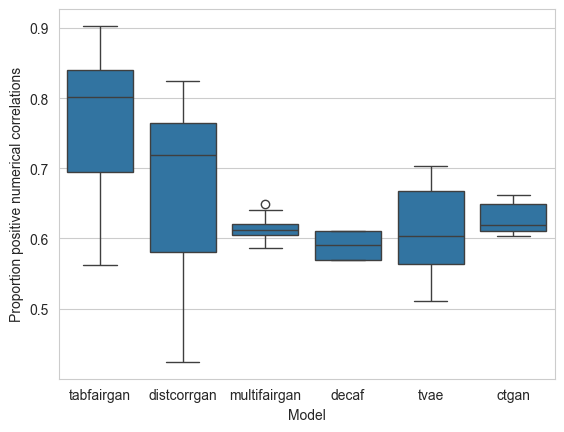

In [25]:
sns.boxplot(x='Model', y='Proportion positive numerical correlations', data=data)

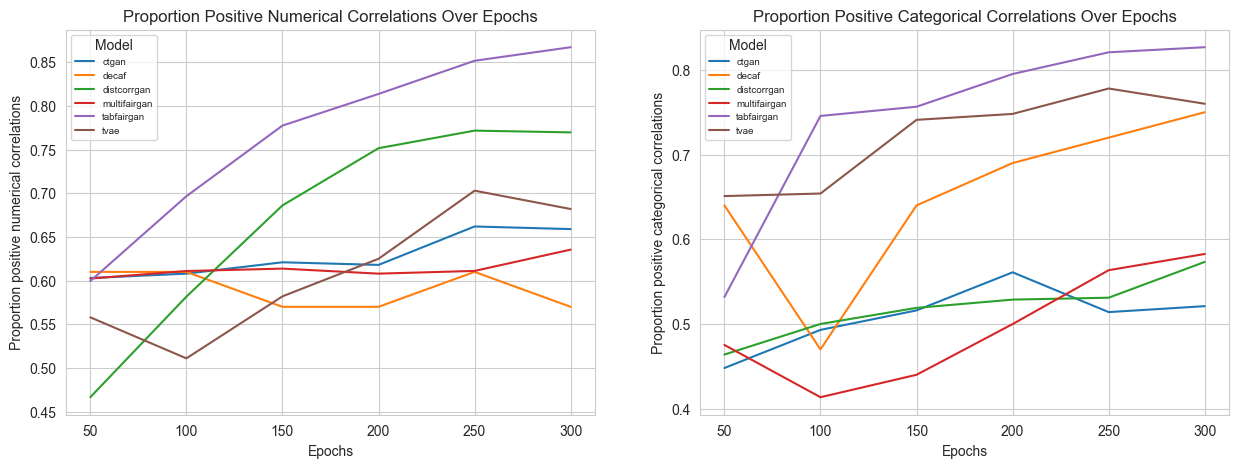

In [32]:
group_numerical_correlations = data.groupby(['Model', 'Epochs'])['Proportion positive numerical correlations'].mean().reset_index()
group_categorical_correlations = data.groupby(['Model', 'Epochs'])['Proportion positive categorical correlations'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot on the first axes
sns.lineplot(x='Epochs', y='Proportion positive numerical correlations', hue='Model', data=group_numerical_correlations, ax=axes[0])
axes[0].set_title('Proportion Positive Numerical Correlations Over Epochs')
sns.move_legend(axes[0], 'upper left', fontsize=7)

# Clear the second axes before plotting 
axes[1].cla()  # Clear the axes

# Plot on the (now cleared) second axes
sns.lineplot(x='Epochs', y='Proportion positive categorical correlations', hue='Model', data=group_categorical_correlations, ax=axes[1])
axes[1].set_title('Proportion Positive Categorical Correlations Over Epochs')
sns.move_legend(axes[1], 'upper left', fontsize=7)

## Data Labelling Analysis

#### Overall DLA Score

<Axes: xlabel='Model', ylabel='DLA Score'>

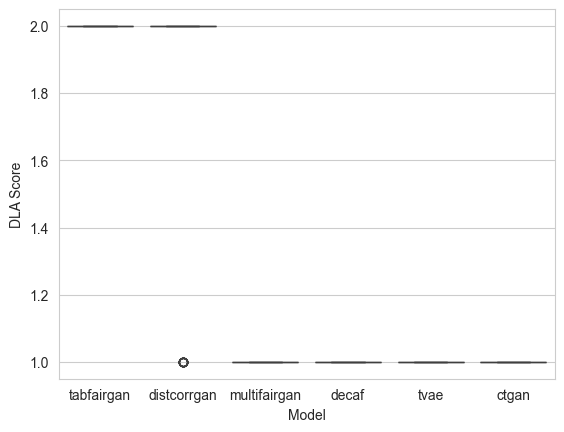

In [27]:
sns.boxplot(x='Model', y='DLA Score', data=data)

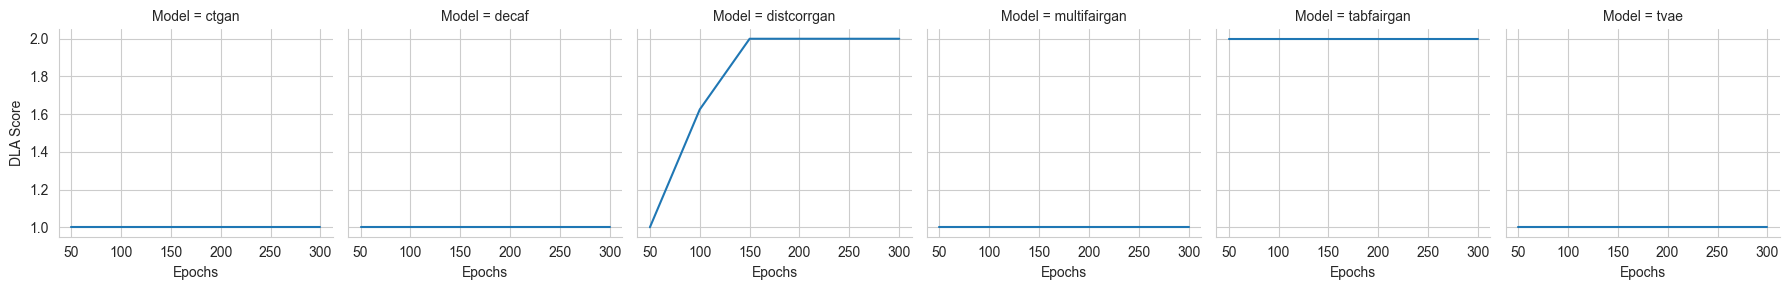

In [29]:
group_dla = data.groupby(['Model', 'Epochs'])['DLA Score'].mean().reset_index()

fg = sns.FacetGrid(data=group_dla, col='Model')
fg.map(sns.lineplot, 'Epochs', 'DLA Score', data=group_dla)

#### Average DLA

<Axes: xlabel='Model', ylabel='Average DLA'>

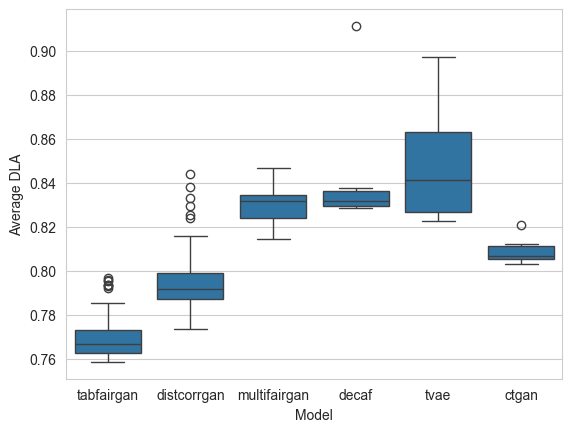

In [30]:
sns.boxplot(x='Model', y='Average DLA', data=data)

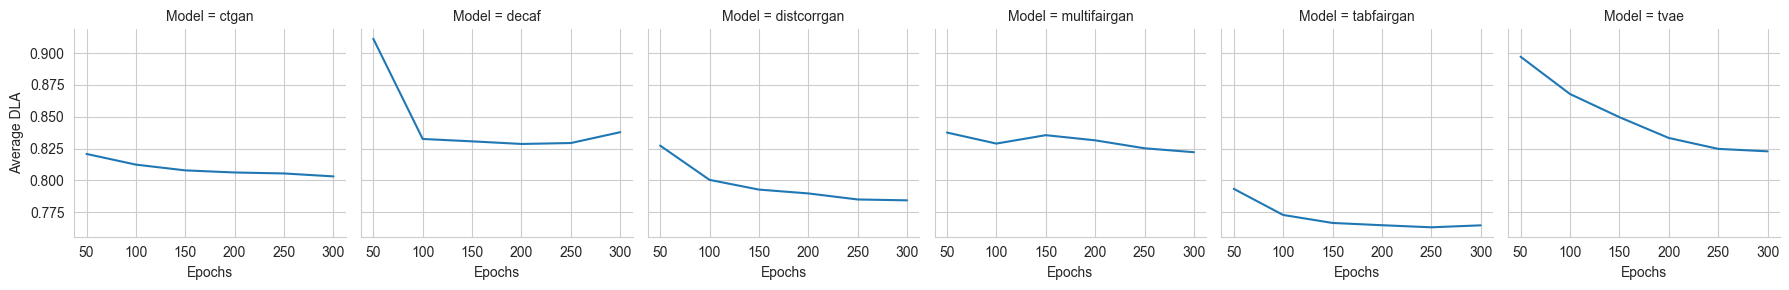

In [31]:
group_average_dla = data.groupby(['Model', 'Epochs'])['Average DLA'].mean().reset_index()

fg = sns.FacetGrid(data=group_average_dla, col='Model')
fg.map(sns.lineplot, 'Epochs', 'Average DLA', data=group_average_dla)